In [1]:
# Cell 1: Install & Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, Concatenate, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print("All libraries loaded! ✅")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries loaded! ✅


5 year flood data generation


In [3]:
# Cell 2: Generate 5 Years Flood Data
np.random.seed(42)

days = 365 * 5
hours = days * 24
timestamps = pd.date_range(start='2019-01-01', periods=hours, freq='H')

day_of_year = np.array([t.timetuple().tm_yday for t in timestamps])
hour_of_day = np.array([t.hour for t in timestamps])

monsoon = 50 * np.exp(-0.5 * ((day_of_year - 210) / 30) ** 2)
base_level = 80 + monsoon
noise = np.random.normal(0, 5, hours)

flood_events = np.zeros(hours)
for year in range(5):
    for _ in range(np.random.randint(2, 4)):
        flood_day = np.random.randint(150, 270) + year * 365
        flood_hour = flood_day * 24
        if flood_hour + 84 < hours:
            build = np.linspace(0, np.random.uniform(100, 300), 24)
            peak = np.ones(12) * build[-1]
            recede = np.linspace(build[-1], 0, 48)
            profile = np.concatenate([build, peak, recede])
            end = min(flood_hour + len(profile), hours)
            flood_events[flood_hour:end] += profile[:end-flood_hour]

water_level = np.clip(base_level + noise + flood_events, 0, 500)
flow_rate = np.clip(water_level * 0.08 + np.random.normal(0, 1, hours), 0, 50)
rainfall = np.clip(np.roll(water_level - 80, -8) * 0.3 + np.random.exponential(2, hours), 0, 100)
soil_moisture = np.clip(30 + np.convolve(rainfall, np.ones(24)/24, mode='same') * 2 + np.random.normal(0, 3, hours), 0, 100)
pressure = 1013 - monsoon * 0.3 - flood_events * 0.05 + np.random.normal(0, 2, hours)
temp_seasonal = 25 + 10 * np.sin(2 * np.pi * day_of_year / 365 - np.pi/2)
temperature = temp_seasonal + 5 * np.sin(2 * np.pi * hour_of_day / 24 - np.pi/2) + np.random.normal(0, 2, hours)

df = pd.DataFrame({
    'water_level': water_level, 'flow_rate': flow_rate,
    'rainfall': rainfall, 'soil_moisture': soil_moisture,
    'pressure': pressure, 'temperature': temperature,
}, index=timestamps)

print("Dataset:", df.shape[0], "rows x", df.shape[1], "columns")
print("Period:", timestamps[0].date(), "to", timestamps[-1].date())
print("")
print("Water Level Stats:")
print("  Min:", round(df.water_level.min(), 1), "cm")
print("  Max:", round(df.water_level.max(), 1), "cm")
print("  Mean:", round(df.water_level.mean(), 1), "cm")
print("")
flood_hours = (df.water_level > 300).sum()
print("Flood events (>300cm):", flood_hours, "hours")
print("Data generated! Done!")

Dataset: 43800 rows x 6 columns
Period: 2019-01-01 to 2023-12-30

Water Level Stats:
  Min: 58.5 cm
  Max: 388.7 cm
  Mean: 92.9 cm

Flood events (>300cm): 217 hours
Data generated! Done!


data preparation for lstm

In [4]:
# Cell 3: Prepare Data for LSTM
feature_cols = ['water_level', 'flow_rate', 'rainfall', 'soil_moisture', 'pressure', 'temperature']
data = df[feature_cols].values

# Normalize (0 to 1)
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Save scaler for Raspberry Pi
with open('data_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved!")

# Create sequences: 7 days input -> predict 24h, 48h, 72h ahead
SEQ_LENGTH = 168  # 7 days hourly
HORIZONS = [24, 48, 72]

def create_sequences(data, seq_len, horizons):
    X, y = [], []
    max_h = max(horizons)
    for i in range(seq_len, len(data) - max_h):
        X.append(data[i - seq_len:i, :])
        targets = [data[i + h - 1, 0] for h in horizons]
        y.append(targets)
    return np.array(X), np.array(y)

print("Creating sequences (this takes ~30 seconds)...")
X, y = create_sequences(data_normalized, SEQ_LENGTH, HORIZONS)

# Split: 70% train, 15% val, 15% test (chronological)
n_train = int(0.7 * len(X))
n_val = int(0.15 * len(X))

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

print("")
print("X shape:", X.shape, "(samples, 168 timesteps, 6 features)")
print("y shape:", y.shape, "(samples, 3 horizons)")
print("")
print("Train:", X_train.shape[0], "samples")
print("Val:  ", X_val.shape[0], "samples")
print("Test: ", X_test.shape[0], "samples")
print("Data prepared! Done!")

Scaler saved!
Creating sequences (this takes ~30 seconds)...

X shape: (43560, 168, 6) (samples, 168 timesteps, 6 features)
y shape: (43560, 3) (samples, 3 horizons)

Train: 30491 samples
Val:   6534 samples
Test:  6535 samples
Data prepared! Done!


lstm + Attention model bulid

In [6]:
# Cell 4: Build LSTM Model (Fixed)
from tensorflow.keras.layers import Attention

inputs = Input(shape=(168, 6), name='sensor_input')

x = Bidirectional(LSTM(64, return_sequences=True, name='lstm_1'))(inputs)
x = LayerNormalization()(x)
x = Dropout(0.2)(x)

lstm_seq = LSTM(32, return_sequences=True, name='lstm_2')(x)
last_hidden = LSTM(32, return_sequences=False, name='lstm_final')(x)

# Attention layer (Keras native - no tf.nn needed)
attn_out = Attention(name='attention')([lstm_seq, lstm_seq])
context = tf.keras.layers.GlobalAveragePooling1D()(attn_out)

combined = Concatenate()([last_hidden, context])
x = Dense(64, activation='relu')(combined)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(3, activation='linear', name='predictions')(x)

model = Model(inputs=inputs, outputs=outputs, name='FloodLSTM')

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae']
)

model.summary()
print("")
print("Model built! Ready to train!")

Model: "FloodLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 168, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 168, 128)  │     36,352 │ sensor_input[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 168, 128)  │        256 │ bidirectional_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 168, 128)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 168, 32)   │     20,608 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 168, 32)   │          0 │ lstm_2[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_final (LSTM)   │ (None, 32)        │     20,608 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ lstm_final[0][0], │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 3)         │         99 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 84,163 (328.76 KB)

 Trainable params: 84,163 (328.76 KB)

 Non-trainable params: 0 (0.00 B)


Model built! Ready to train!


In [7]:
# Cell 5: TRAIN THE MODEL! 🚀
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, monitor='val_loss'),
]

print("=" * 50)
print("  TRAINING STARTED - GPU: T4")
print("  This will take ~10-15 minutes")
print("  Watch the loss go DOWN!")
print("=" * 50)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

print("")
print("=" * 50)
print("  TRAINING COMPLETE!")
print("  Best val_loss:", round(min(history.history['val_loss']), 6))
print("=" * 50)

  TRAINING STARTED - GPU: T4
  This will take ~10-15 minutes
  Watch the loss go DOWN!
Epoch 1/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0018 - mae: 0.0268 - val_loss: 0.0017 - val_mae: 0.0211 - learning_rate: 0.0010
Epoch 2/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0013 - mae: 0.0208 - val_loss: 0.0016 - val_mae: 0.0219 - learning_rate: 0.0010
Epoch 3/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0012 - mae: 0.0204 - val_loss: 0.0017 - val_mae: 0.0211 - learning_rate: 0.0010
Epoch 4/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.0012 - mae: 0.0204 - val_loss: 0.0018 - val_mae: 0.0216 - learning_rate: 0.0010
Epoch 5/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0011 - mae: 0.0200 - val_loss: 0.0016 - val_mae: 0.0204 - learning_rate: 0.0010
Epoch 6/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0011 - mae: 0.0198 - val_loss: 0.0019 - val_mae: 0.0218 - learning_rate: 0.0010
Epoch 7/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 15

205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
  MODEL ACCURACY ON TEST DATA

24-Hour Prediction:
  RMSE: 8.34 cm
  MAE:  5.03 cm
  EXCELLENT!

48-Hour Prediction:
  RMSE: 20.24 cm
  MAE:  6.94 cm
  VERY GOOD!

72-Hour Prediction:
  RMSE: 24.36 cm
  MAE:  8.09 cm
  VERY GOOD!



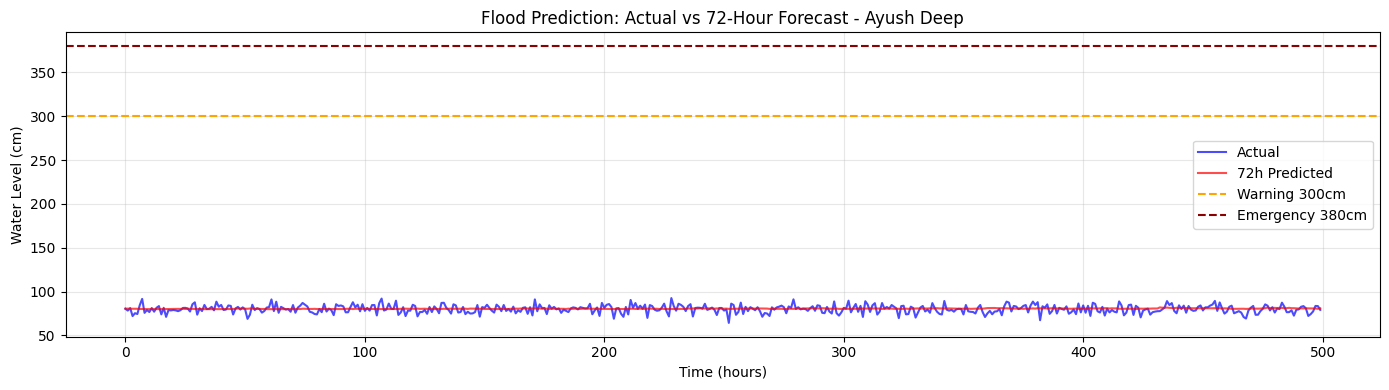

Graph saved!


In [9]:
# Cell 6: EVALUATE
y_pred = model.predict(X_test)

def denormalize(values):
    dummy = np.zeros((len(values), 6))
    dummy[:, 0] = values
    return scaler.inverse_transform(dummy)[:, 0]

print("=" * 50)
print("  MODEL ACCURACY ON TEST DATA")
print("=" * 50)

for i, hours in enumerate([24, 48, 72]):
    y_true_cm = denormalize(y_test[:, i])
    y_pred_cm = denormalize(y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true_cm, y_pred_cm))
    mae = mean_absolute_error(y_true_cm, y_pred_cm)
    print("")
    print(str(hours) + "-Hour Prediction:")
    print("  RMSE: " + str(round(rmse, 2)) + " cm")
    print("  MAE:  " + str(round(mae, 2)) + " cm")
    if rmse < 20:
        print("  EXCELLENT!")
    elif rmse < 30:
        print("  VERY GOOD!")
    elif rmse < 50:
        print("  GOOD")

print("")
print("=" * 50)

plt.figure(figsize=(14, 4))
actual = denormalize(y_test[:500, 2])
predicted = denormalize(y_pred[:500, 2])
plt.plot(actual, label='Actual', color='blue', alpha=0.7)
plt.plot(predicted, label='72h Predicted', color='red', alpha=0.7)
plt.axhline(y=300, color='orange', linestyle='--', label='Warning 300cm')
plt.axhline(y=380, color='darkred', linestyle='--', label='Emergency 380cm')
plt.xlabel('Time (hours)')
plt.ylabel('Water Level (cm)')
plt.title('Flood Prediction: Actual vs 72-Hour Forecast - Ayush Deep')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150)
plt.show()
print("Graph saved!")

In [12]:
# Cell 7: Save as .keras + .h5 (Pi pe directly use karenge)
# Method 1: Save full Keras model
model.save('flood_model.keras')
print("Keras model saved!")

# Method 2: Save as H5
model.save('flood_model.h5')
print("H5 model saved!")

# Method 3: Save weights only
model.save_weights('flood_weights.weights.h5')
print("Weights saved!")

# Verify model works
test_pred = model.predict(X_test[:1])
print("")
print("Test prediction:", test_pred[0])
print("")

# Check file sizes
import os
for f in ['flood_model.keras', 'flood_model.h5', 'data_scaler.pkl']:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024*1024)
        print(f + " : " + str(round(size, 2)) + " MB")

print("")
print("=" * 50)
print("  MODELS SAVED SUCCESSFULLY!")
print("=" * 50)
print("")
print("  Download these files from left sidebar:")
print("  1. flood_model.h5 (for Raspberry Pi)")
print("  2. data_scaler.pkl (for normalization)")
print("  3. prediction_results.png (for report)")
print("")
print("  Pi pe use: tf.keras.models.load_model('flood_model.h5')")
print("=" * 50)

Keras model saved!
H5 model saved!
Weights saved!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step

Test prediction: [0.06904307 0.06801081 0.06631554]

flood_model.keras : 1.04 MB
flood_model.h5 : 1.04 MB
data_scaler.pkl : 0.0 MB

  MODELS SAVED SUCCESSFULLY!

  Download these files from left sidebar:
  1. flood_model.h5 (for Raspberry Pi)
  2. data_scaler.pkl (for normalization)
  3. prediction_results.png (for report)

  Pi pe use: tf.keras.models.load_model('flood_model.h5')
